<a href="https://colab.research.google.com/github/Mathildeholst/Speciale/blob/main/Da_Audio_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load the DA_Audio data set

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, shutil

drive_path = "/content/drive/MyDrive/Da_Audio"
local_path = "/content/da_audio"

if not os.path.exists(local_path):
    shutil.copytree(drive_path, local_path)

base_path = local_path
train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "validation")
test_path = os.path.join(base_path, "test")

for split, split_name in [("train", "train"), ("validation", "val"), ("test", "test")]:
    for label in ["real", "fake"]:
        path = os.path.join(base_path, split, f"{label}_{split_name}_audio")
        if os.path.exists(path):
            count = len([f for f in os.listdir(path) if f.endswith('.wav')])
            print(f"{split}/{label}: {count} files")

Mounted at /content/drive
train/real: 5405 files
train/fake: 5405 files
validation/real: 1088 files
validation/fake: 1088 files
test/real: 1100 files
test/fake: 1100 files


In [ ]:
real_path = os.path.join(test_path, "real_test_audio")
fake_path = os.path.join(test_path, "fake_test_audio")

#Load best two models

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import tensorflow as tf

simple_cnn_mfcc = tf.keras.models.load_model('/content/drive/MyDrive/simple_cnn_mfcc.keras')

In [ ]:
import tensorflow as tf

vgg19_opt_cqt = tf.keras.models.load_model('/content/drive/MyDrive/vgg19_opt_cqt.keras')

#Improved VGG19 on DA_Audio test

###Imports and parameters

In [ ]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR              = 16000
DURATION        = 2.0
TARGET_LEN      = int(SR * DURATION)
HOP_LENGTH      = 256
FMIN            = 32.7
N_BINS          = 168
BINS_PER_OCTAVE = 24

CQT funktion and load data

In [ ]:
def create_cqt(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    C = librosa.cqt(
        audio, sr=SR,
        hop_length=HOP_LENGTH,
        fmin=FMIN,
        n_bins=N_BINS,
        bins_per_octave=BINS_PER_OCTAVE
    )
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
    return C_db.astype(np.float32)

def get_paths(real_path, fake_path):
    real = sorted([
        os.path.join(real_path, f)
        for f in os.listdir(real_path)
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(fake_path, f)
        for f in os.listdir(fake_path)
        if f.endswith(".wav")
    ])
    return real, fake

def load_new_test(real_path, fake_path):
    real, fake = get_paths(real_path, fake_path)
    X, y = [], []
    for fp in real:
        X.append(create_cqt(fp))
        y.append(1)
    for fp in fake:
        X.append(create_cqt(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading new test data...")
X_new_test, y_new_test = load_new_test(real_path, fake_path)

print("New Test:", X_new_test.shape)
print(f"Data range: {X_new_test.min():.2f} to {X_new_test.max():.2f}")

Loading new test data...


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=500
  warnings.warn(


New Test: (2200, 168, 126)
Data range: -80.00 to 0.00


RGB conversions

In [ ]:
def to_rgb_resized(X, size):
    results = []
    for spec in X:
        spec_rgb = np.stack([spec, spec, spec], axis=-1)
        spec_resized = tf.image.resize(spec_rgb, (size, size)).numpy()
        results.append(spec_resized)
    return np.array(results, dtype=np.float32)

print("Converting to RGB...")
X_new_test_vgg = to_rgb_resized(X_new_test, 224)

print("VGG 224:", X_new_test_vgg.shape)
print(f"VGG data range: {X_new_test_vgg.min():.2f} to {X_new_test_vgg.max():.2f}")

Converting to RGB...
VGG 224: (2200, 224, 224, 3)
VGG data range: -80.00 to 0.00


Preprocessing

In [ ]:
from tensorflow.keras.applications.vgg19 import preprocess_input

def to_vgg_optimized_from_rgb(X_rgb):
    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)
        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)
    return np.array(X_out)

X_new_test_vgg_opt = to_vgg_optimized_from_rgb(X_new_test_vgg)
print("VGG Optimized shape:", X_new_test_vgg_opt.shape)

VGG Optimized shape: (2200, 224, 224, 3)


Evaluation functions

In [ ]:
def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

Evaluate on Da_Audio

In [ ]:
results_vgg = evaluate_model(vgg19_opt_cqt, X_new_test_vgg_opt, y_new_test, "VGG19 Optimized");


=== VGG19 Optimized ===
Accuracy:  0.4968
Recall:    0.6382
Precision: 0.4975
F1-score:  0.5591
AUC-ROC:   0.5465
EER:       0.4664
Bootstrap: 0.4966 [0.4745, 0.5191]


###ACAM

Using layer: block5_conv4
Applying VGG19 preprocessing (flipud + preprocess_input)...
Computing activations for real samples...
Computing activations for fake samples...


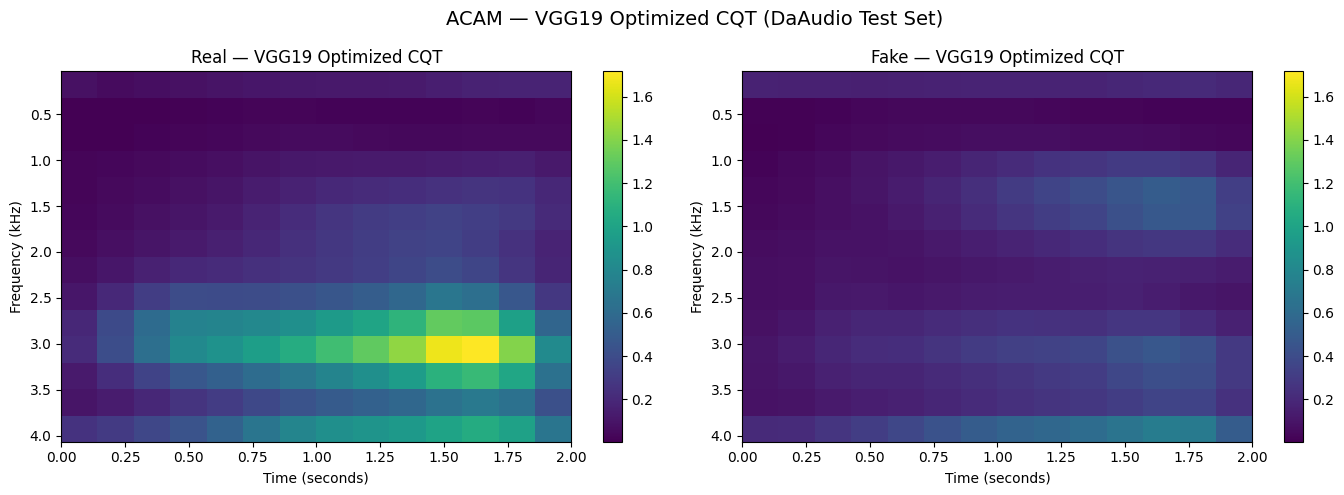


ACAM visualization complete!
Time axis: 0 to 2.0 seconds
Frequency axis: 0.03 to 4.07 kHz
ACAM shape: (14, 14) (freq_bins × time_bins)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg19 import preprocess_input

def get_activations_vgg(model, X, layer_name):
    feature_model = tf.keras.Model(
        inputs=model.input,
        outputs=model.get_layer(layer_name).output
    )
    return feature_model.predict(X, verbose=0)

def compute_acam(activations):
    return np.mean(activations, axis=(0, -1))

def to_vgg_optimized_from_rgb(X_rgb):
    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)
        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)
    return np.array(X_out, dtype=np.float32)

base_vgg = None
for layer in vgg19_opt_cqt.layers:
    if 'vgg19' in layer.name.lower():
        base_vgg = layer
        break

last_conv_layer = None
if base_vgg:
    for layer in reversed(base_vgg.layers):
        if 'conv' in layer.name:
            last_conv_layer = layer.name
            break
print(f"Using layer: {last_conv_layer}")

X_test_real_raw = X_new_test_vgg[y_new_test == 1]
X_test_fake_raw = X_new_test_vgg[y_new_test == 0]

print("Applying VGG19 preprocessing (flipud + preprocess_input)...")
X_test_real = to_vgg_optimized_from_rgb(X_test_real_raw)
X_test_fake = to_vgg_optimized_from_rgb(X_test_fake_raw)

print("Computing activations for real samples...")
act_real = get_activations_vgg(base_vgg, X_test_real, last_conv_layer)
print("Computing activations for fake samples...")
act_fake = get_activations_vgg(base_vgg, X_test_fake, last_conv_layer)

acam_real = compute_acam(act_real)
acam_fake = compute_acam(act_fake)

vmin = min(acam_real.min(), acam_fake.min())
vmax = max(acam_real.max(), acam_fake.max())

FMIN = 32.7
BINS_PER_OCTAVE = 24
N_BINS = 168
DURATION = 2.0
SR = 16000

freq_bins = librosa.cqt_frequencies(n_bins=N_BINS, fmin=FMIN, bins_per_octave=BINS_PER_OCTAVE)
freq_khz = freq_bins / 1000

time_max = DURATION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(acam_real, aspect='auto', origin='lower', cmap='viridis',
                     vmin=vmin, vmax=vmax,
                     extent=[0, time_max, freq_khz[-1], freq_khz[0]])
axes[0].set_title('Real — VGG19 Optimized CQT')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Frequency (kHz)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(acam_fake, aspect='auto', origin='lower', cmap='viridis',
                     vmin=vmin, vmax=vmax,
                     extent=[0, time_max, freq_khz[-1], freq_khz[0]])
axes[1].set_title('Fake — VGG19 Optimized CQT')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Frequency (kHz)')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('ACAM — VGG19 Optimized CQT (DaAudio Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nACAM visualization complete!")
print(f"Time axis: 0 to {time_max} seconds")
print(f"Frequency axis: {freq_khz[0]:.2f} to {freq_khz[-1]:.2f} kHz")
print(f"ACAM shape: {acam_real.shape} (freq_bins × time_bins)")

#Simple CNN on DA_Audio test

###Imports and parameters

In [ ]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR         = 16000
DURATION   = 2.0
TARGET_LEN = int(SR * DURATION)
N_MFCC     = 40
N_FFT      = 1024
HOP_LENGTH = 256
BATCH_SIZE = 16
EPOCHS     = 50
INITIAL_LR = 5e-5
PATIENCE   = 10

MFCC function and load data

In [ ]:
def create_mfcc(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    mfcc = librosa.feature.mfcc(
        y=audio, sr=SR, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    return mfcc.astype(np.float32)

def get_paths(real_path, fake_path):
    real = sorted([
        os.path.join(real_path, f)
        for f in os.listdir(real_path)
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(fake_path, f)
        for f in os.listdir(fake_path)
        if f.endswith(".wav")
    ])
    return real, fake

def load_split(real_path, fake_path):
    real, fake = get_paths(real_path, fake_path)
    X, y = [], []
    for fp in real:
        X.append(create_mfcc(fp))
        y.append(1)
    for fp in fake:
        X.append(create_mfcc(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading Data...")
X_new_train, y_new_train = load_split(
    os.path.join(train_path, "real_train_audio"),
    os.path.join(train_path, "fake_train_audio")
)
X_new_val, y_new_val = load_split(
    os.path.join(val_path, "real_val_audio"),
    os.path.join(val_path, "fake_val_audio")
)
X_new_test, y_new_test = load_split(
    os.path.join(test_path, "real_test_audio"),
    os.path.join(test_path, "fake_test_audio")
)

print("Train:", X_new_train.shape)
print("Val:  ", X_new_val.shape)
print("Test: ", X_new_test.shape)

Loading Data...
Train: (10810, 40, 126)
Val:   (2176, 40, 126)
Test:  (2200, 40, 126)


Z-score normalization

In [ ]:
print("Z-score normalizing for custom CNNs...")

mean = X_new_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_new_train.std(axis=(0, 1, 2), keepdims=True) + 1e-8

X_new_train_norm = (X_new_train - mean) / std
X_new_val_norm   = (X_new_val   - mean) / std
X_new_test_norm  = (X_new_test  - mean) / std

X_new_train_norm = X_new_train_norm[..., np.newaxis]
X_new_val_norm   = X_new_val_norm[..., np.newaxis]
X_new_test_norm  = X_new_test_norm[..., np.newaxis]

print("Normalized train shape:", X_new_train_norm.shape)
print("Normalized val shape:  ", X_new_val_norm.shape)
print("Normalized test shape: ", X_new_test_norm.shape)
print(f"\nZ-scored data - Mean: {X_new_train_norm.mean():.6f}, Std: {X_new_train_norm.std():.6f}")
print(f"Z-scored range: {X_new_train_norm.min():.2f} to {X_new_train_norm.max():.2f}")

Z-score normalizing for custom CNNs...
Normalized train shape: (10810, 40, 126, 1)
Normalized val shape:   (2176, 40, 126, 1)
Normalized test shape:  (2200, 40, 126, 1)

Z-scored data - Mean: -0.000000, Std: 1.000000
Z-scored range: -15.18 to 4.00


Evaluation functions

In [ ]:
def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")



Evaluate on DA_Audio

In [ ]:
evaluate_model(simple_cnn_mfcc, X_new_test_norm, y_new_test, "Simple CNN MFCC")


=== Simple CNN MFCC ===
Accuracy:  0.6695
Recall:    0.5145
Precision: 0.7457
F1-score:  0.6089
AUC-ROC:   0.6912
EER:       0.3555
Bootstrap: 0.6697 [0.6500, 0.6886]


##ACAM

Using layer: conv2d_2


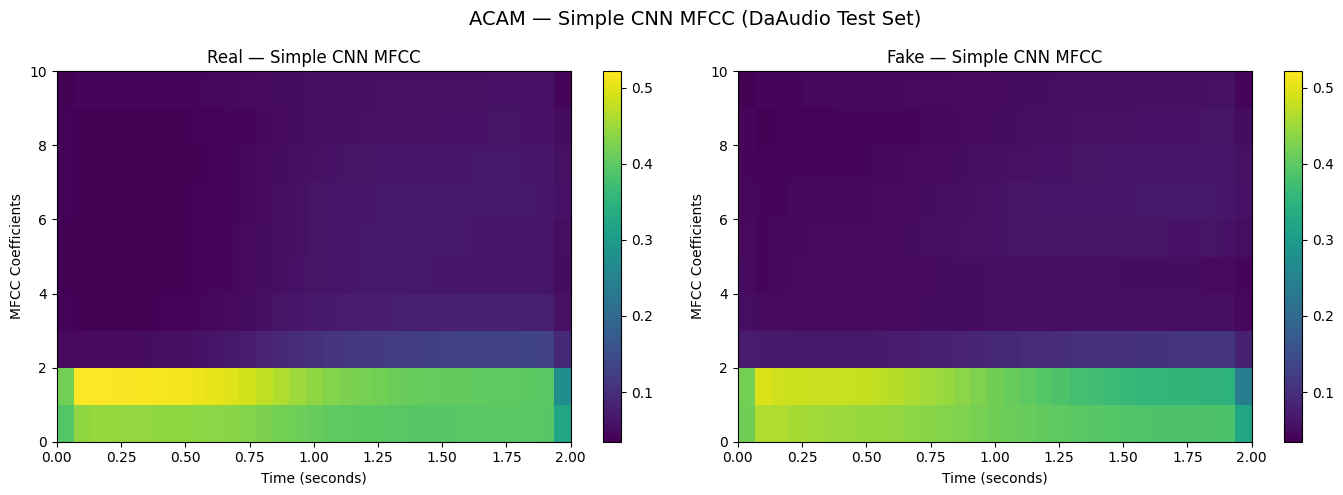


ACAM visualization complete!
Time axis: 0 to 2.0 seconds
ACAM shape: (10, 31) (mfcc_coefficients × time_bins)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_activations(model, X, layer_name):
    feature_model = tf.keras.Model(
        inputs=model.layers[0].input,
        outputs=model.get_layer(layer_name).output
    )
    return feature_model.predict(X, verbose=0)

def compute_acam(activations):
    return np.mean(activations, axis=(0, -1))

last_conv_layer = None
for layer in reversed(simple_cnn_mfcc.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break
print(f"Using layer: {last_conv_layer}")

X_test_real = X_new_test_norm[y_new_test == 1]
X_test_fake = X_new_test_norm[y_new_test == 0]

act_real = get_activations(simple_cnn_mfcc, X_test_real, last_conv_layer)
act_fake = get_activations(simple_cnn_mfcc, X_test_fake, last_conv_layer)

acam_real = compute_acam(act_real)
acam_fake = compute_acam(act_fake)

vmin = min(acam_real.min(), acam_fake.min())
vmax = max(acam_real.max(), acam_fake.max())

DURATION = 2.0
n_coeffs = acam_real.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(acam_real, aspect='auto', origin='lower', cmap='viridis',
                     vmin=vmin, vmax=vmax,
                     extent=[0, DURATION, 0, n_coeffs])
axes[0].set_title('Real — Simple CNN MFCC')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('MFCC Coefficients')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(acam_fake, aspect='auto', origin='lower', cmap='viridis',
                     vmin=vmin, vmax=vmax,
                     extent=[0, DURATION, 0, n_coeffs])
axes[1].set_title('Fake — Simple CNN MFCC')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('MFCC Coefficients')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('ACAM — Simple CNN MFCC (DaAudio Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nACAM visualization complete!")
print(f"Time axis: 0 to {DURATION} seconds")
print(f"ACAM shape: {acam_real.shape} (mfcc_coefficients × time_bins)")

#Retrain models on DA_Audio

### Improved VGG19

In [ ]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR              = 16000
DURATION        = 5.0
TARGET_LEN      = int(SR * DURATION)
HOP_LENGTH      = 256
FMIN            = 32.7
N_BINS          = 168
BINS_PER_OCTAVE = 24
BATCH_SIZE      = 16
EPOCHS          = 50
INITIAL_LR      = 5e-5
PATIENCE        = 10

base_path  = "/content/da_audio"
train_path = os.path.join(base_path, "train")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "test")

CQT function and load data

In [ ]:
def create_cqt(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    C = librosa.cqt(
        audio, sr=SR,
        hop_length=HOP_LENGTH,
        fmin=FMIN,
        n_bins=N_BINS,
        bins_per_octave=BINS_PER_OCTAVE
    )
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
    return C_db.astype(np.float32)

def get_paths_cqt(split_path, split_name):
    """split_name: 'train', 'val', or 'test'"""
    real = sorted([
        os.path.join(split_path, f"real_{split_name}_audio", f)
        for f in os.listdir(os.path.join(split_path, f"real_{split_name}_audio"))
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(split_path, f"fake_{split_name}_audio", f)
        for f in os.listdir(os.path.join(split_path, f"fake_{split_name}_audio"))
        if f.endswith(".wav")
    ])
    return real, fake

def load_split_cqt(split_path, split_name):
    real, fake = get_paths_cqt(split_path, split_name)
    X, y = [], []
    print(f"Loading {split_name} CQT features...")
    for fp in real:
        X.append(create_cqt(fp))
        y.append(1)
    for fp in fake:
        X.append(create_cqt(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading Danish Data with CQT...")
X_train_cqt, y_train = load_split_cqt(train_path, "train")
X_val_cqt, y_val = load_split_cqt(val_path, "val")
X_test_cqt, y_test = load_split_cqt(test_path, "test")

print("\nTrain:", X_train_cqt.shape)
print("Val:  ", X_val_cqt.shape)
print("Test: ", X_test_cqt.shape)
print(f"Data range: {X_train_cqt.min():.2f} to {X_train_cqt.max():.2f}")

Loading Danish Data with CQT...
Loading train CQT features...
Loading val CQT features...
Loading test CQT features...

Train: (10810, 168, 313)
Val:   (2176, 168, 313)
Test:  (2200, 168, 313)
Data range: -80.00 to 0.00


RGB conversion

In [ ]:
def to_rgb_resized(X, size):
    """Convert grayscale spectrograms to RGB and resize."""
    results = []
    for spec in X:
        spec_rgb = np.stack([spec, spec, spec], axis=-1)
        spec_resized = tf.image.resize(spec_rgb, (size, size)).numpy()
        results.append(spec_resized)
    return np.array(results, dtype=np.float32)

print("Converting CQT to RGB 224x224...")
X_train_vgg = to_rgb_resized(X_train_cqt, 224)
X_val_vgg   = to_rgb_resized(X_val_cqt, 224)
X_test_vgg  = to_rgb_resized(X_test_cqt, 224)

print("VGG 224:", X_train_vgg.shape)
print(f"RGB data range: {X_train_vgg.min():.2f} to {X_train_vgg.max():.2f}")

Converting CQT to RGB 224x224...
VGG 224: (10810, 224, 224, 3)
RGB data range: -80.00 to -0.01


Preprocessing

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

def to_vgg_optimized_from_rgb(X_rgb):
    """Preprocess: flipud + preprocess_input"""
    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)

        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)

        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)
    return np.array(X_out, dtype=np.float32)

print("Applying VGG19 preprocessing (flipud + preprocess_input)...")
X_train_opt = to_vgg_optimized_from_rgb(X_train_vgg)
X_val_opt   = to_vgg_optimized_from_rgb(X_val_vgg)
X_test_opt  = to_vgg_optimized_from_rgb(X_test_vgg)

print("Preprocessed train:", X_train_opt.shape)
print(f"Preprocessed range: {X_train_opt.min():.2f} to {X_train_opt.max():.2f}")

Applying VGG19 preprocessing (flipud + preprocess_input)...
Preprocessed train: (10810, 224, 224, 3)
Preprocessed range: -203.68 to -103.94


Help functions

In [ ]:
class CosineAnnealingScheduler(Callback):
    def __init__(self, T_max, eta_max, eta_min=1e-6, verbose=0):
        super().__init__()
        self.T_max   = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.eta_max - self.eta_min) * (
            1 + math.cos(math.pi * epoch / self.T_max)
        ) / 2
        self.model.optimizer.learning_rate.assign(lr)
        if self.verbose:
            print(f"  LR: {lr:.2e}")

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=EPOCHS, eta_max=INITIAL_LR, eta_min=1e-6),
        ModelCheckpoint(
            f"/content/drive/MyDrive/{model_name}_danish.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

def plot_history(history, model_name):
    best_val_acc = max(history.history["val_accuracy"])
    print(f"Best val accuracy ({model_name}): {best_val_acc:.4f}")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{model_name} – Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{model_name} – Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout(); plt.show()

Train model

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,090,177 (76.64 MB)

 Trainable params: 9,505,025 (36.26 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

Epoch 1/50
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9582 - loss: 0.1193
Epoch 1: val_loss improved from None to 0.02416, saving model to /content/drive/MyDrive/vgg19_opt_cqt_danish_danish.keras

Epoch 1: finished saving model to /content/drive/MyDrive/vgg19_opt_cqt_danish_danish.keras
676/676 ━━━━━━━━━━━━━━━━━━━━ 157s 212ms/step - accuracy: 0.9839 - loss: 0.0470 - val_accuracy: 0.9908 - val_loss: 0.0242
Epoch 2/50
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9971 - loss: 0.0103
Epoch 2: val_loss improved from 0.02416 to 0.01672, saving model to /content/drive/MyDrive/vgg19_opt_cqt_danish_danish.keras

Epoch 2: finished saving model to /content/drive/MyDrive/vgg19_opt_cqt_danish_danish.keras
676/676 ━━━━━━━━━━━━━━━━━━━━ 134s 198ms/step - accuracy: 0.9973 - loss: 0.0088 - val_accuracy: 0.9963 - val_loss: 0.0167
Epoch 3/50
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9950 - loss: 0.0154
Epoch 3: val_loss improved from 0.01672 to 0.01350, saving mode

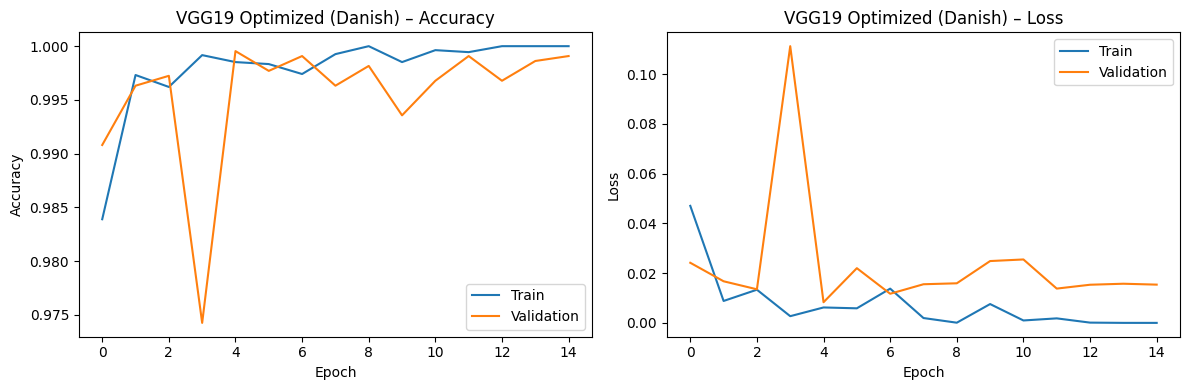


=== VGG19 Optimized (Danish) ===
Accuracy:  0.7973
Recall:    0.9955
Precision: 0.7129
F1-score:  0.8308
AUC-ROC:   0.9842
EER:       0.0336
Bootstrap: 0.7971 [0.7804, 0.8145]


In [ ]:
base_model = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-5:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg19_opt = models.Model(inputs, outputs)

vgg19_opt.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg19_opt.summary()

history_vgg19_opt = vgg19_opt.fit(
    X_train_opt, y_train,
    validation_data=(X_val_opt, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg19_opt_cqt_danish")
)

plot_history(history_vgg19_opt, "VGG19 Optimized (Danish)")
results_vgg19_opt = evaluate_model(vgg19_opt, X_test_opt, y_test, "VGG19 Optimized (Danish)")

###ACAM

Load model

In [ ]:
vgg19_opt_cqt_danish = tf.keras.models.load_model('/content/drive/MyDrive/vgg19_opt_cqt_danish_danish.keras')
print("VGG19 Optimized CQT Danish loaded!")

VGG19 Optimized CQT Danish loaded!


Generate ACAM plot

Using layer: block5_conv4
Applying VGG19 preprocessing (flipud + preprocess_input)...
Computing activations for real samples...
Computing activations for fake samples...


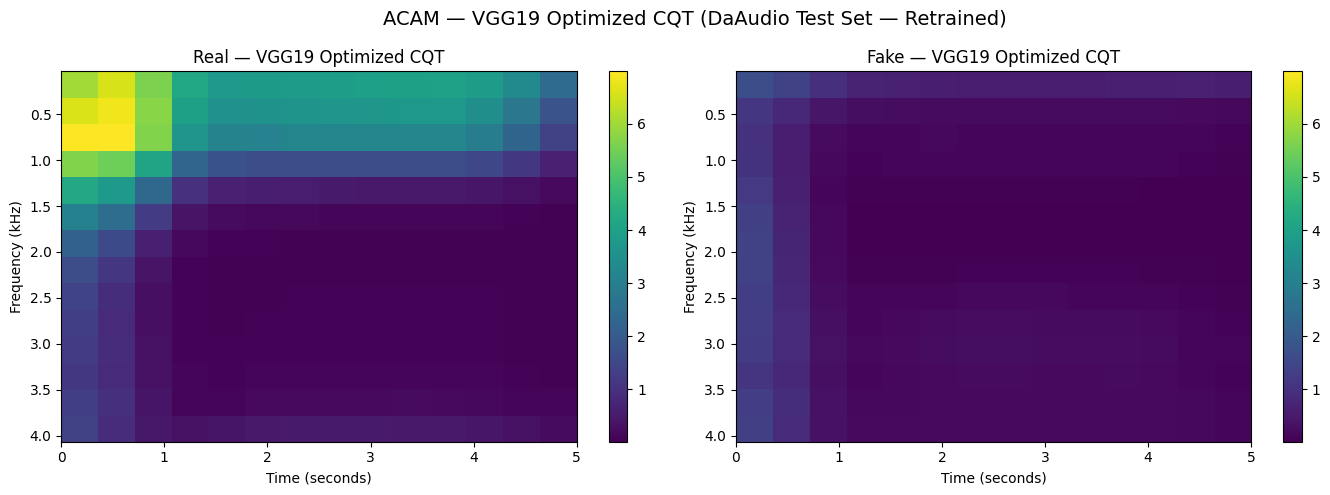


ACAM visualization complete!
Time axis: 0 to 5.0 seconds
Frequency axis: 0.03 to 4.07 kHz
ACAM shape: (14, 14) (freq_bins × time_bins)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg19 import preprocess_input

def get_activations_vgg(model, X, layer_name):
    feature_model = tf.keras.Model(
        inputs=model.input,
        outputs=model.get_layer(layer_name).output
    )
    return feature_model.predict(X, verbose=0)

def compute_acam(activations):
    return np.mean(activations, axis=(0, -1))

def to_vgg_optimized_from_rgb(X_rgb):
    """Preprocess from already-resized RGB data (224x224x3)."""
    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)
        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)
    return np.array(X_out, dtype=np.float32)

base_vgg = None
for layer in vgg19_opt_cqt_danish.layers:
    if 'vgg19' in layer.name.lower():
        base_vgg = layer
        break

last_conv_layer = None
if base_vgg:
    for layer in reversed(base_vgg.layers):
        if 'conv' in layer.name:
            last_conv_layer = layer.name
            break

print(f"Using layer: {last_conv_layer}")

X_test_real_raw = X_test_vgg[y_test == 1]
X_test_fake_raw = X_test_vgg[y_test == 0]

print("Applying VGG19 preprocessing (flipud + preprocess_input)...")
X_test_real = to_vgg_optimized_from_rgb(X_test_real_raw)
X_test_fake = to_vgg_optimized_from_rgb(X_test_fake_raw)

print("Computing activations for real samples...")
act_real = get_activations_vgg(base_vgg, X_test_real, last_conv_layer)
print("Computing activations for fake samples...")
act_fake = get_activations_vgg(base_vgg, X_test_fake, last_conv_layer)

acam_real = compute_acam(act_real)
acam_fake = compute_acam(act_fake)

vmin = min(acam_real.min(), acam_fake.min())
vmax = max(acam_real.max(), acam_fake.max())

FMIN = 32.7
BINS_PER_OCTAVE = 24
N_BINS = 168
HOP_LENGTH_CQT = 256
SR = 16000
DURATION = 5.0

freq_bins = librosa.cqt_frequencies(n_bins=N_BINS, fmin=FMIN, bins_per_octave=BINS_PER_OCTAVE)
freq_khz = freq_bins / 1000

time_bins = acam_real.shape[1]
time_frames = np.arange(time_bins)
time_max = DURATION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(acam_real, aspect='auto', origin='lower', cmap='viridis',
                     vmin=vmin, vmax=vmax,
                     extent=[0, time_max, freq_khz[-1], freq_khz[0]])
axes[0].set_title('Real — VGG19 Optimized CQT')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Frequency (kHz)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(acam_fake, aspect='auto', origin='lower', cmap='viridis',
                     vmin=vmin, vmax=vmax,
                     extent=[0, time_max, freq_khz[-1], freq_khz[0]])
axes[1].set_title('Fake — VGG19 Optimized CQT')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Frequency (kHz)')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('ACAM — VGG19 Optimized CQT (DaAudio Test Set — Retrained)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nACAM visualization complete!")
print(f"Time axis: 0 to {time_max} seconds")
print(f"Frequency axis: {freq_khz[0]:.2f} to {freq_khz[-1]:.2f} kHz")
print(f"ACAM shape: {acam_real.shape} (freq_bins × time_bins)")

###Simple CNN

In [ ]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR          = 16000
DURATION    = 5.0
TARGET_LEN  = int(SR * DURATION)
N_MFCC      = 40
N_FFT       = 1024
HOP_LENGTH  = 256
BATCH_SIZE  = 16
EPOCHS      = 50
INITIAL_LR  = 5e-5
PATIENCE    = 10

base_path  = "/content/da_audio"
train_path = os.path.join(base_path, "train")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "test")

MFCC function and load data

In [ ]:
def create_mfcc(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    mfcc = librosa.feature.mfcc(
        y=audio, sr=SR, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    return mfcc.astype(np.float32)

def get_paths(split_path, split_name):
    """
    split_name: 'train', 'val', or 'test'
    Da_Audio structure: real_train_audio, fake_train_audio, etc.
    """
    real = sorted([
        os.path.join(split_path, f"real_{split_name}_audio", f)
        for f in os.listdir(os.path.join(split_path, f"real_{split_name}_audio"))
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(split_path, f"fake_{split_name}_audio", f)
        for f in os.listdir(os.path.join(split_path, f"fake_{split_name}_audio"))
        if f.endswith(".wav")
    ])
    return real, fake

def load_split(split_path, split_name):
    real, fake = get_paths(split_path, split_name)
    X, y = [], []
    print(f"Loading {split_name}: {len(real)} real + {len(fake)} fake files...")
    for fp in real:
        X.append(create_mfcc(fp))
        y.append(1)
    for fp in fake:
        X.append(create_mfcc(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading Danish Data...")
X_train, y_train = load_split(train_path, "train")
X_val, y_val = load_split(val_path, "val")
X_test, y_test = load_split(test_path, "test")

print("\nTrain:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)
print(f"Data range: {X_train.min():.2f} to {X_train.max():.2f}")

Loading Danish Data...
Loading train: 5405 real + 5405 fake files...
Loading val: 1088 real + 1088 fake files...
Loading test: 1100 real + 1100 fake files...

Train: (10810, 40, 313)
Val:   (2176, 40, 313)
Test:  (2200, 40, 313)
Data range: -1131.37 to 286.86


Z-score normalization

In [ ]:
print("Z-score normalizing for Simple CNN...")

mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-8

X_train_norm = (X_train - mean) / std
X_val_norm   = (X_val   - mean) / std
X_test_norm  = (X_test  - mean) / std

X_train_norm = X_train_norm[..., np.newaxis]
X_val_norm   = X_val_norm[..., np.newaxis]
X_test_norm  = X_test_norm[..., np.newaxis]

print("Normalized train shape:", X_train_norm.shape)
print("Normalized val shape:  ", X_val_norm.shape)
print("Normalized test shape: ", X_test_norm.shape)

print(f"\nZ-scored data - Mean: {X_train_norm.mean():.6f}, Std: {X_train_norm.std():.6f}")
print(f"Z-scored range: {X_train_norm.min():.2f} to {X_train_norm.max():.2f}")

Z-score normalizing for Simple CNN...
Normalized train shape: (10810, 40, 313, 1)
Normalized val shape:   (2176, 40, 313, 1)
Normalized test shape:  (2200, 40, 313, 1)

Z-scored data - Mean: -0.000000, Std: 1.000000
Z-scored range: -15.83 to 4.21


Help functions

In [ ]:
class CosineAnnealingScheduler(Callback):
    def __init__(self, T_max, eta_max, eta_min=1e-6, verbose=0):
        super().__init__()
        self.T_max   = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.eta_max - self.eta_min) * (
            1 + math.cos(math.pi * epoch / self.T_max)
        ) / 2
        self.model.optimizer.learning_rate.assign(lr)
        if self.verbose:
            print(f"  LR: {lr:.2e}")

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=EPOCHS, eta_max=INITIAL_LR, eta_min=1e-6),
        ModelCheckpoint(
            f"/content/drive/MyDrive/{model_name}_danish.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

def plot_history(history, model_name):
    best_val_acc = max(history.history["val_accuracy"])
    print(f"Best val accuracy ({model_name}): {best_val_acc:.4f}")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{model_name} – Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{model_name} – Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout(); plt.show()

Train model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 313, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 156, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 156, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 39, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       798,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,145 (3.14 MB)

 Trainable params: 822,145 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9043 - loss: 0.2981
Epoch 1: val_loss improved from None to 0.06040, saving model to /content/drive/MyDrive/simple_cnn_mfcc_danish.keras

Epoch 1: finished saving model to /content/drive/MyDrive/simple_cnn_mfcc_danish.keras
676/676 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9529 - loss: 0.1627 - val_accuracy: 0.9917 - val_loss: 0.0604
Epoch 2/50
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9808 - loss: 0.0628
Epoch 2: val_loss improved from 0.06040 to 0.03969, saving model to /content/drive/MyDrive/simple_cnn_mfcc_danish.keras

Epoch 2: finished saving model to /content/drive/MyDrive/simple_cnn_mfcc_danish.keras
676/676 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9812 - loss: 0.0598 - val_accuracy: 0.9936 - val_loss: 0.0397
Epoch 3/50
670/676 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9840 - loss: 0.0483
Epoch 3: val_loss improved from 0.03969 to 0.03562, saving model to /content/drive/MyDrive/simpl

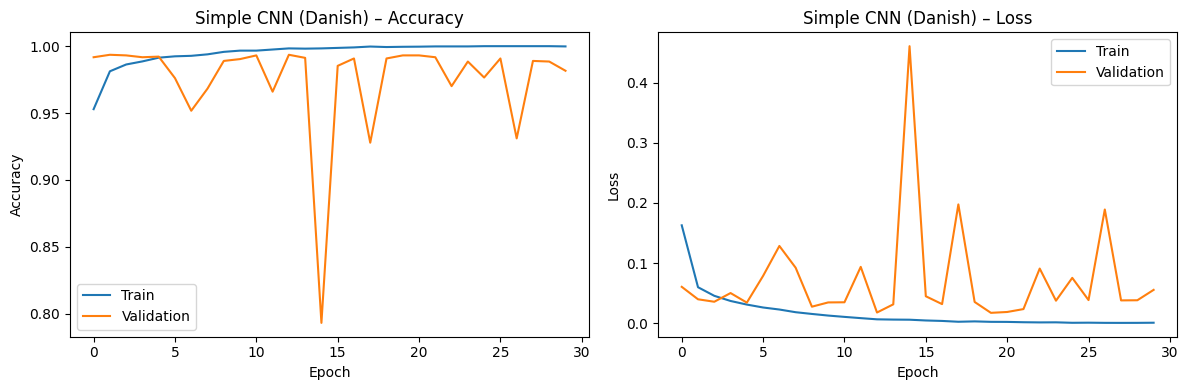


=== Simple CNN (Danish) ===
Accuracy:  0.8505
Recall:    0.9873
Precision: 0.7752
F1-score:  0.8685
AUC-ROC:   0.9870
EER:       0.0536
Bootstrap: 0.8501 [0.8355, 0.8650]


In [ ]:
input_shape = X_train_norm.shape[1:]
simple_cnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

simple_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
simple_cnn.summary()

history_simple = simple_cnn.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("simple_cnn_mfcc")
)

plot_history(history_simple, "Simple CNN (Danish)")
results_simple = evaluate_model(simple_cnn, X_test_norm, y_test, "Simple CNN (Danish)")

##ACAM

Load model

In [ ]:
import tensorflow as tf

simple_cnn_danish = tf.keras.models.load_model('/content/drive/MyDrive/simple_cnn_mfcc_danish.keras')
print("Simple CNN Danish loaded!")

Simple CNN Danish loaded!


Generate ACAM plot

Using layer: conv2d_2


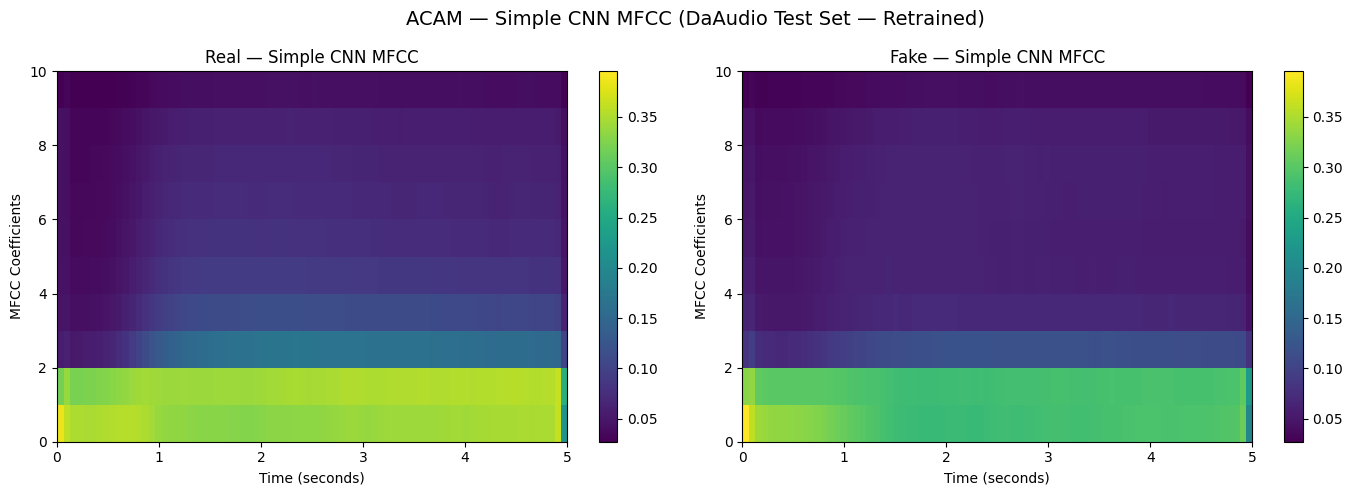


ACAM visualization complete!
Time axis: 0 to 5.0 seconds
ACAM shape: (10, 78) (mfcc_coefficients × time_bins)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_activations(model, X, layer_name):
    feature_model = tf.keras.Model(
        inputs=model.layers[0].input,
        outputs=model.get_layer(layer_name).output
    )
    return feature_model.predict(X, verbose=0)

def compute_acam(activations):
    return np.mean(activations, axis=(0, -1))

last_conv_layer = None
for layer in reversed(simple_cnn_danish.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break
print(f"Using layer: {last_conv_layer}")

X_test_real = X_test_norm[y_test == 1]
X_test_fake = X_test_norm[y_test == 0]

act_real = get_activations(simple_cnn_danish, X_test_real, last_conv_layer)
act_fake = get_activations(simple_cnn_danish, X_test_fake, last_conv_layer)

acam_real = compute_acam(act_real)
acam_fake = compute_acam(act_fake)

vmin = min(acam_real.min(), acam_fake.min())
vmax = max(acam_real.max(), acam_fake.max())

DURATION = 5.0
n_coeffs = acam_real.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(acam_real, aspect='auto', origin='lower', cmap='viridis',
                     vmin=vmin, vmax=vmax,
                     extent=[0, DURATION, 0, n_coeffs])
axes[0].set_title('Real — Simple CNN MFCC')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('MFCC Coefficients')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(acam_fake, aspect='auto', origin='lower', cmap='viridis',
                     vmin=vmin, vmax=vmax,
                     extent=[0, DURATION, 0, n_coeffs])
axes[1].set_title('Fake — Simple CNN MFCC')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('MFCC Coefficients')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('ACAM — Simple CNN MFCC (DaAudio Test Set — Retrained)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nACAM visualization complete!")
print(f"Time axis: 0 to {DURATION} seconds")
print(f"ACAM shape: {acam_real.shape} (mfcc_coefficients × time_bins)")

#Ensemble

Mount drive and imports

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Helper functions

In [ ]:
def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

Load saved models from drive

In [ ]:
try:
    simple_cnn = tf.keras.models.load_model(
        "/content/drive/MyDrive/simple_cnn_mfcc_danish.keras",
        compile=False
    )
    print("Simple CNN (MFCC) loaded!")
except Exception as e:
    print(f"Could not load Simple CNN: {e}")
    simple_cnn = None

try:
    vgg19_opt = tf.keras.models.load_model(
        "/content/drive/MyDrive/vgg19_opt_cqt_danish_danish.keras",
        compile=False
    )
    print("VGG19 Optimized (CQT) loaded!")
except Exception as e:
    print(f"Could not load VGG19: {e}")
    vgg19_opt = None

if simple_cnn and vgg19_opt:
    print("\n Both models loaded successfully!")
else:
    print("\n Some models failed to load - check file names in Drive")

Simple CNN (MFCC) loaded!
VGG19 Optimized (CQT) loaded!

 Both models loaded successfully!


Copy test data from drive

In [ ]:
drive_test_path = "/content/drive/MyDrive/Da_Audio/test"
local_test_path = "/content/da_audio_test"

if not os.path.exists(local_test_path):
    print("Copying test data from Drive to local storage...")
    shutil.copytree(drive_test_path, local_test_path)
    print("Test data copied!")
else:
    print("Test data already exists locally")

test_path = local_test_path

Copying test data from Drive to local storage...
Test data copied!


Parameters for data loading

In [ ]:
SR          = 16000
DURATION    = 5.0
TARGET_LEN  = int(SR * DURATION)

N_MFCC      = 40
N_FFT       = 1024
HOP_LENGTH_MFCC = 256

HOP_LENGTH_CQT = 256
FMIN           = 32.7
N_BINS         = 168
BINS_PER_OCTAVE = 24

Load MFCC test data

In [ ]:
def create_mfcc(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    mfcc = librosa.feature.mfcc(
        y=audio, sr=SR, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LENGTH_MFCC
    )
    return mfcc.astype(np.float32)

def load_test_mfcc():
    real = sorted([
        os.path.join(test_path, "real_test_audio", f)
        for f in os.listdir(os.path.join(test_path, "real_test_audio"))
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(test_path, "fake_test_audio", f)
        for f in os.listdir(os.path.join(test_path, "fake_test_audio"))
        if f.endswith(".wav")
    ])
    X, y = [], []
    print(f"Loading MFCC test data: {len(real)} real + {len(fake)} fake...")
    for fp in real:
        X.append(create_mfcc(fp))
        y.append(1)
    for fp in fake:
        X.append(create_mfcc(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading MFCC test data...")
X_test_mfcc, y_test = load_test_mfcc()

mean = X_test_mfcc.mean(axis=(0, 1, 2), keepdims=True)
std  = X_test_mfcc.std(axis=(0, 1, 2), keepdims=True) + 1e-8
X_test_norm = (X_test_mfcc - mean) / std
X_test_norm = X_test_norm[..., np.newaxis]

print(f"MFCC Test data loaded: {X_test_norm.shape}")
print(f"   Labels: {len(y_test)} samples")

Loading MFCC test data...
Loading MFCC test data: 1100 real + 1100 fake...
MFCC Test data loaded: (2200, 40, 313, 1)
   Labels: 2200 samples


Load CQT test data

In [ ]:
def create_cqt(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    C = librosa.cqt(
        audio, sr=SR,
        hop_length=HOP_LENGTH_CQT,
        fmin=FMIN,
        n_bins=N_BINS,
        bins_per_octave=BINS_PER_OCTAVE
    )
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
    return C_db.astype(np.float32)

def load_test_cqt():
    real = sorted([
        os.path.join(test_path, "real_test_audio", f)
        for f in os.listdir(os.path.join(test_path, "real_test_audio"))
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(test_path, "fake_test_audio", f)
        for f in os.listdir(os.path.join(test_path, "fake_test_audio"))
        if f.endswith(".wav")
    ])
    X = []
    print(f"Loading CQT test data: {len(real)} real + {len(fake)} fake...")
    for fp in real + fake:
        X.append(create_cqt(fp))
    return np.array(X, dtype=np.float32)

print("Loading CQT test data...")
X_test_cqt = load_test_cqt()
print(f"CQT raw data loaded: {X_test_cqt.shape}")

Loading CQT test data...
Loading CQT test data: 1100 real + 1100 fake...
CQT raw data loaded: (2200, 168, 313)


Preprocess CQT for VGG19

In [ ]:
from tensorflow.keras.applications.vgg19 import preprocess_input

def to_vgg_format(X_cqt):
    """Convert CQT to VGG19 format: RGB 224x224, flipud, preprocess"""
    results = []
    for spec in X_cqt:
        spec_rgb = np.stack([spec, spec, spec], axis=-1)


        spec_resized = tf.image.resize(spec_rgb, (224, 224)).numpy()
        results.append(spec_resized)

    X_rgb = np.array(results, dtype=np.float32)

    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)
        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)

    return np.array(X_out, dtype=np.float32)

print("Converting CQT to VGG19 format...")
X_test_opt = to_vgg_format(X_test_cqt)
print(f"VGG19 test data ready: {X_test_opt.shape}")

Converting CQT to VGG19 format...
VGG19 test data ready: (2200, 224, 224, 3)


##Simple CNN (MFCC) + improved VGG19 (CQT)

In [ ]:
print("\n" + "="*70)
print("ENSEMBLE: Simple CNN (MFCC) + VGG19 Optimized (CQT)")
print("="*70)

print("\nGetting Simple CNN predictions...")
pred_simple = simple_cnn.predict(X_test_norm, verbose=0).ravel()
print(f"   Done! Shape: {pred_simple.shape}")

print("\nGetting VGG19 predictions...")
pred_vgg19 = vgg19_opt.predict(X_test_opt, verbose=0).ravel()
print(f"   Done! Shape: {pred_vgg19.shape}")

print("\n" + "="*70)
print("ENSEMBLE STRATEGY: SIMPLE AVERAGE (50-50)")
print("="*70)

pred_ensemble = (pred_simple + pred_vgg19) / 2
y_pred_ensemble = (pred_ensemble >= 0.5).astype(int)

acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
recall_ensemble = recall_score(y_test, y_pred_ensemble)
precision_ensemble = precision_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble)
auc_ensemble = roc_auc_score(y_test, pred_ensemble)
eer_ensemble = equal_error_rate(y_test, pred_ensemble)
mean_acc, ci_low, ci_high = bootstrap_ci(y_test, pred_ensemble)

print(f"\nAccuracy:  {acc_ensemble:.4f}")
print(f"Recall:    {recall_ensemble:.4f}")
print(f"Precision: {precision_ensemble:.4f}")
print(f"F1-score:  {f1_ensemble:.4f}")
print(f"AUC-ROC:   {auc_ensemble:.4f}")
print(f"EER:       {eer_ensemble:.4f}")
print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print(f"Simple CNN (MFCC):     83.18% accuracy")
print(f"VGG19 (CQT):           79.73% accuracy")
print(f"ENSEMBLE (Average):    {acc_ensemble:.4f} accuracy")
print(f"\nBoost from best:       {(acc_ensemble - 0.8318)*100:+.2f}%")
print("="*70)


ENSEMBLE: Simple CNN (MFCC) + VGG19 Optimized (CQT)

Getting Simple CNN predictions...
   Done! Shape: (2200,)

Getting VGG19 predictions...
   Done! Shape: (2200,)

ENSEMBLE STRATEGY: SIMPLE AVERAGE (50-50)

Accuracy:  0.8318
Recall:    0.9927
Precision: 0.7510
F1-score:  0.8551
AUC-ROC:   0.9895
EER:       0.0527
Bootstrap: 0.8318 [0.8164, 0.8473]

COMPARISON:
Simple CNN (MFCC):     83.18% accuracy
VGG19 (CQT):           79.73% accuracy
ENSEMBLE (Average):    0.8318 accuracy

Boost from best:       +0.00%


In [ ]:
pred_ensemble_weighted = (0.7 * pred_simple) + (0.3 * pred_vgg19)
y_pred_weighted = (pred_ensemble_weighted >= 0.5).astype(int)

acc_weighted = accuracy_score(y_test, y_pred_weighted)
recall_weighted = recall_score(y_test, y_pred_weighted)
precision_weighted = precision_score(y_test, y_pred_weighted)
f1_weighted = f1_score(y_test, y_pred_weighted)
auc_weighted = roc_auc_score(y_test, pred_ensemble_weighted)
eer_weighted = equal_error_rate(y_test, pred_ensemble_weighted)
mean_acc_weighted, ci_low_weighted, ci_high_weighted = bootstrap_ci(y_test, pred_ensemble_weighted)

print("\n" + "="*70)
print("ENSEMBLE STRATEGY: WEIGHTED AVERAGE (70% Simple CNN, 30% VGG19)")
print("="*70)

print(f"\nAccuracy:  {acc_weighted:.4f}")
print(f"Recall:    {recall_weighted:.4f}")
print(f"Precision: {precision_weighted:.4f}")
print(f"F1-score:  {f1_weighted:.4f}")
print(f"AUC-ROC:   {auc_weighted:.4f}")
print(f"EER:       {eer_weighted:.4f}")
print(f"Bootstrap: {mean_acc_weighted:.4f} [{ci_low_weighted:.4f}, {ci_high_weighted:.4f}]")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print(f"Simple CNN (MFCC):        83.18% accuracy")
print(f"VGG19 (CQT):              79.73% accuracy")
print(f"Ensemble (50-50):         83.18% accuracy")
print(f"Ensemble (70-30 Weighted): {acc_weighted:.4f} accuracy")
print(f"\nBoost from Simple CNN:    {(acc_weighted - 0.8318)*100:+.2f}%")
print(f"Boost from 50-50:         {(acc_weighted - 0.8318)*100:+.2f}%")
print("="*70)


ENSEMBLE STRATEGY: WEIGHTED AVERAGE (70% Simple CNN, 30% VGG19)

Accuracy:  0.8445
Recall:    0.9900
Precision: 0.7669
F1-score:  0.8643
AUC-ROC:   0.9886
EER:       0.0518
Bootstrap: 0.8444 [0.8282, 0.8591]

COMPARISON:
Simple CNN (MFCC):        83.18% accuracy
VGG19 (CQT):              79.73% accuracy
Ensemble (50-50):         83.18% accuracy
Ensemble (70-30 Weighted): 0.8445 accuracy

Boost from Simple CNN:    +1.27%
Boost from 50-50:         +1.27%


#Intentional test-to-train overlap

##Improved VGG19

Mount drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR              = 16000
DURATION        = 5.0
TARGET_LEN      = int(SR * DURATION)
HOP_LENGTH      = 256
FMIN            = 32.7
N_BINS          = 168
BINS_PER_OCTAVE = 24
BATCH_SIZE      = 16
EPOCHS          = 50
INITIAL_LR      = 5e-5
PATIENCE        = 10

drive_path = "/content/drive/MyDrive/Da_Audio"
local_path = "/content/da_audio"

if not os.path.exists(local_path):
    shutil.copytree(drive_path, local_path)

base_path  = local_path
train_path = os.path.join(base_path, "train")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "test")

for split, split_name in [("train", "train"), ("validation", "val"), ("test", "test")]:
    for label in ["real", "fake"]:
        path = os.path.join(base_path, split, f"{label}_{split_name}_audio")
        if os.path.exists(path):
            count = len([f for f in os.listdir(path) if f.endswith('.wav')])
            print(f"{split}/{label}: {count} files")

from google.colab import files

print("Upload test_real.csv:")
uploaded = files.upload()

print("\nUpload test_fake.csv:")
uploaded = files.upload()

Mounted at /content/drive
train/real: 5405 files
train/fake: 5405 files
validation/real: 1088 files
validation/fake: 1088 files
test/real: 1100 files
test/fake: 1100 files
Upload test_real.csv:


Saving test_real.csv to test_real.csv

Upload test_fake.csv:


Saving test_fake.csv to test_fake.csv


Speaker movement functions

In [ ]:
def load_speaker_mapping():
    df_real = pd.read_csv("/content/test_real.csv", sep=';')
    real_mapping = dict(zip(df_real['id'] + '.wav', df_real['user']))

    df_fake = pd.read_csv("/content/test_fake.csv", sep=',')
    fake_mapping = dict(zip(df_fake['id'], df_fake['speaker']))

    return {'real': real_mapping, 'fake': fake_mapping}


def move_speakers(test_path, train_path, csv_mapping, n_speakers=2):
    stats = {'real': [], 'fake': []}

    for class_name in ['real', 'fake']:
        test_dir = os.path.join(test_path, f"{class_name}_test_audio")
        train_dir = os.path.join(train_path, f"{class_name}_train_audio")
        mapping = csv_mapping[class_name]

        speakers = defaultdict(list)
        for f in os.listdir(test_dir):
            if f.endswith('.wav') and f in mapping:
                speakers[mapping[f]].append(f)

        top_speakers = sorted(speakers.items(), key=lambda x: len(x[1]), reverse=True)[:n_speakers]

        for speaker_id, files in top_speakers:
            stats[class_name].append(speaker_id)
            for filename in files:
                shutil.move(os.path.join(test_dir, filename), os.path.join(train_dir, filename))

    return stats


csv_mapping = load_speaker_mapping()
stats = move_speakers(test_path, train_path, csv_mapping, n_speakers=2)

print("Speakers moved:")
print(f"Real: {len(stats['real'])} speakers")
print(f"Fake: {len(stats['fake'])} speakers")

Speakers moved:
Real: 2 speakers
Fake: 2 speakers


Load new training data

In [ ]:
def create_cqt(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    C = librosa.cqt(audio, sr=SR, hop_length=HOP_LENGTH, fmin=FMIN, n_bins=N_BINS, bins_per_octave=BINS_PER_OCTAVE)
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
    return C_db.astype(np.float32)

def get_paths(split_path, split_name):
    real = sorted([os.path.join(split_path, f"real_{split_name}_audio", f)
                   for f in os.listdir(os.path.join(split_path, f"real_{split_name}_audio"))
                   if f.endswith(".wav")])
    fake = sorted([os.path.join(split_path, f"fake_{split_name}_audio", f)
                   for f in os.listdir(os.path.join(split_path, f"fake_{split_name}_audio"))
                   if f.endswith(".wav")])
    return real, fake

def load_cqt_split(split_path, split_name):
    real, fake = get_paths(split_path, split_name)
    X, y = [], []
    for fp in real:
        X.append(create_cqt(fp))
        y.append(1)
    for fp in fake:
        X.append(create_cqt(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading data...")
X_train_cqt, y_train = load_cqt_split(train_path, "train")
X_val_cqt, y_val = load_cqt_split(val_path, "val")
X_test_cqt, y_test = load_cqt_split(test_path, "test")

print(f"Train: {X_train_cqt.shape}")
print(f"Val: {X_val_cqt.shape}")
print(f"Test: {X_test_cqt.shape}")

Loading data...
Train: (11126, 168, 313)
Val: (2176, 168, 313)
Test: (1884, 168, 313)


Check for data leakage

In [ ]:
from collections import defaultdict

def verify_no_overlap_csv(test_path, train_path, csv_mapping):
    print("\n" + "="*70)
    print("VERIFICATION: Checking for speaker overlap")
    print("="*70)

    all_good = True

    for class_name in ['real', 'fake']:
        test_dir = os.path.join(test_path, f"{class_name}_test_audio")
        train_dir = os.path.join(train_path, f"{class_name}_train_audio")
        mapping = csv_mapping[class_name]

        test_speakers = set()
        for f in os.listdir(test_dir):
            if f.endswith('.wav') and f in mapping:
                test_speakers.add(mapping[f])

        train_speakers = set()
        for f in os.listdir(train_dir):
            if f.endswith('.wav') and f in mapping:
                train_speakers.add(mapping[f])

        overlap = test_speakers & train_speakers

        print(f"\n{class_name.upper()}:")
        print(f"  Test speakers:  {len(test_speakers)}")
        print(f"  Train speakers: {len(train_speakers)}")
        print(f"  Overlap:        {len(overlap)}")

        if overlap:
            print(f"WARNING: Overlap!")
            all_good = False
        else:
            print(f"NO OVERLAP!")

    print("\n" + "="*70)
    if all_good:
        print("PERFECT! No data leakage!")
    else:
        print("PROBLEM! Overlap detected!")
    print("="*70 + "\n")

    return all_good

verify_no_overlap_csv(test_path, train_path, csv_mapping)


VERIFICATION: Checking for speaker overlap

REAL:
  Test speakers:  72
  Train speakers: 2
  Overlap:        0
NO OVERLAP!

FAKE:
  Test speakers:  10
  Train speakers: 2
  Overlap:        0
NO OVERLAP!

PERFECT! No data leakage!



True

Pre-process for improved VGG19

In [ ]:
def to_rgb_resized(X, size):
    """Convert grayscale spectrograms to RGB and resize."""
    results = []
    for spec in X:
        spec_rgb = np.stack([spec, spec, spec], axis=-1)
        spec_resized = tf.image.resize(spec_rgb, (size, size)).numpy()
        results.append(spec_resized)
    return np.array(results, dtype=np.float32)

print("\nConverting CQT to RGB 224x224...")
X_train_vgg = to_rgb_resized(X_train_cqt, 224)
X_val_vgg   = to_rgb_resized(X_val_cqt, 224)
X_test_vgg  = to_rgb_resized(X_test_cqt, 224)

print("VGG 224:", X_train_vgg.shape)
print(f"RGB data range: {X_train_vgg.min():.2f} to {X_train_vgg.max():.2f}")

from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

def to_vgg_optimized_from_rgb(X_rgb):
    """Preprocess: flipud + preprocess_input"""
    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)
        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)
    return np.array(X_out, dtype=np.float32)

print("\nApplying VGG19 preprocessing (flipud + preprocess_input)...")
X_train_opt = to_vgg_optimized_from_rgb(X_train_vgg)
X_val_opt   = to_vgg_optimized_from_rgb(X_val_vgg)
X_test_opt  = to_vgg_optimized_from_rgb(X_test_vgg)

print("Preprocessed train:", X_train_opt.shape)
print(f"Preprocessed range: {X_train_opt.min():.2f} to {X_train_opt.max():.2f}")


Converting CQT to RGB 224x224...
VGG 224: (11126, 224, 224, 3)
RGB data range: -80.00 to -0.01

Applying VGG19 preprocessing (flipud + preprocess_input)...
Preprocessed train: (11126, 224, 224, 3)
Preprocessed range: -203.68 to -103.94


Callbacks and evaluation functions

In [ ]:
class CosineAnnealingScheduler(Callback):
    def __init__(self, T_max, eta_max, eta_min=1e-6, verbose=0):
        super().__init__()
        self.T_max   = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.eta_max - self.eta_min) * (
            1 + math.cos(math.pi * epoch / self.T_max)
        ) / 2
        self.model.optimizer.learning_rate.assign(lr)
        if self.verbose:
            print(f"  LR: {lr:.2e}")

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=EPOCHS, eta_max=INITIAL_LR, eta_min=1e-6),
        ModelCheckpoint(
            f"/content/drive/MyDrive/{model_name}.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

def plot_history(history, model_name):
    best_val_acc = max(history.history["val_accuracy"])
    print(f"Best val accuracy ({model_name}): {best_val_acc:.4f}")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{model_name} – Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{model_name} – Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout(); plt.show()

Check moved speakers

In [ ]:
print("="*70)
print("CHECKING FAKE SPEAKERS MOVED")
print("="*70)

df_fake = pd.read_csv("/content/test_fake.csv", sep=',')
print(f"\nFAKE speaker counts in CSV:")
print(df_fake['speaker'].value_counts().head(10))

print(f"\nSpeakers that were moved:")
print(f"FAKE: {stats['fake']}")

for speaker in stats['fake']:
    count = len(df_fake[df_fake['speaker'] == speaker])
    print(f"  Speaker {speaker} had {count} files in test CSV")

train_fake_dir = os.path.join(train_path, "fake_train_audio")
all_fake_files = [f for f in os.listdir(train_fake_dir) if f.endswith('.wav')]
print(f"\nTotal FAKE files in train NOW: {len(all_fake_files)}")
print(f"Expected: 5405 (original) + ? (moved)")

CHECKING FAKE SPEAKERS MOVED

FAKE speaker counts in CSV:
speaker
tor         92
ida         92
liv         92
ask         92
kaj         92
mathilde    92
niels       92
clara       92
freja       91
emil        91
Name: count, dtype: int64

Speakers that were moved:
FAKE: ['ida', 'clara']
  Speaker ida had 92 files in test CSV
  Speaker clara had 92 files in test CSV

Total FAKE files in train NOW: 5589
Expected: 5405 (original) + ? (moved)


In [ ]:
print("\n" + "="*70)
print("CHECKING REAL SPEAKERS MOVED")
print("="*70)

df_real = pd.read_csv("/content/test_real.csv", sep=';')
print(f"\nREAL speaker counts in CSV:")
print(df_real['user'].value_counts().head(10))

print(f"\nSpeakers that were moved:")
print(f"REAL: {[s[:12]+'...' for s in stats['real']]}")

for speaker in stats['real']:
    count = len(df_real[df_real['user'] == speaker])
    print(f"  Speaker {speaker[:12]}... had {count} files in test CSV")

train_real_dir = os.path.join(train_path, "real_train_audio")
all_real_files = [f for f in os.listdir(train_real_dir) if f.endswith('.wav')]
print(f"\nTotal REAL files in train NOW: {len(all_real_files)}")
print(f"Expected: 5405 (original) + ? (moved)")

print(f"\nTOTAL TRAIN:")
print(f"REAL: {len(all_real_files)}")
print(f"FAKE: 5589")
print(f"TOTAL: {len(all_real_files) + 5589} (should match {len(y_train)})")


CHECKING REAL SPEAKERS MOVED

REAL speaker counts in CSV:
user
9cda40a30c968556bfc030890df434d5ed50fe87    84
23803f6c046a66217241323f29b854cc502d8777    48
a8b823dc212ce8d17a654aa88e1105e27875fd83    43
ec051a9ac6317df468241d184e6b8ceae0639c76    42
ad21137a20fa6358489bf80307bf3a378297f7f3    40
e8f7849ce44715597f3d45cef72df47a9d901933    32
49414c04a5adf8f76f3ae6f9bbf4c1f4bb6fb0bb    31
7d8fc1e12352e9d3a063cd7f2d45051b4b5cdc71    29
670eabe66ef54f5490f5a7741d7c6469a23cccf8    28
752a4ccac3a0d3c2b7e97b780b143b2ab1d33c03    26
Name: count, dtype: int64

Speakers that were moved:
REAL: ['9cda40a30c96...', '23803f6c046a...']
  Speaker 9cda40a30c96... had 84 files in test CSV
  Speaker 23803f6c046a... had 48 files in test CSV

Total REAL files in train NOW: 5537
Expected: 5405 (original) + ? (moved)

TOTAL TRAIN:
REAL: 5537
FAKE: 5589
TOTAL: 11126 (should match 11126)


Train model

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,090,177 (76.64 MB)

 Trainable params: 9,505,025 (36.26 MB)

 Non-trainable params: 10,585,152 (40.38 MB)


Training NEW VGG19 Optimized model...
Epoch 1/50
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9547 - loss: 0.1275
Epoch 1: val_loss improved from None to 0.34480, saving model to /content/drive/MyDrive/vgg19_opt_cqt_with_moved_speakers.keras

Epoch 1: finished saving model to /content/drive/MyDrive/vgg19_opt_cqt_with_moved_speakers.keras
696/696 ━━━━━━━━━━━━━━━━━━━━ 177s 236ms/step - accuracy: 0.9836 - loss: 0.0478 - val_accuracy: 0.8621 - val_loss: 0.3448
Epoch 2/50
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9967 - loss: 0.0113
Epoch 2: val_loss improved from 0.34480 to 0.00953, saving model to /content/drive/MyDrive/vgg19_opt_cqt_with_moved_speakers.keras

Epoch 2: finished saving model to /content/drive/MyDrive/vgg19_opt_cqt_with_moved_speakers.keras
696/696 ━━━━━━━━━━━━━━━━━━━━ 149s 213ms/step - accuracy: 0.9954 - loss: 0.0160 - val_accuracy: 0.9991 - val_loss: 0.0095
Epoch 3/50
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9979 - loss: 0.0044


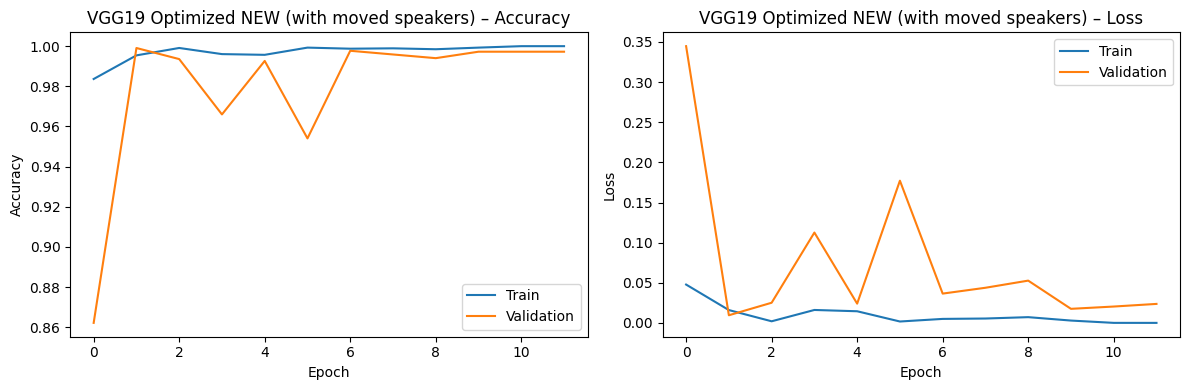

In [ ]:
base_model = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-5:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg19_opt_new = models.Model(inputs, outputs)

vgg19_opt_new.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg19_opt_new.summary()

print("\nTraining NEW VGG19 Optimized model...")

history_vgg19_opt_new = vgg19_opt_new.fit(
    X_train_opt, y_train,
    validation_data=(X_val_opt, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg19_opt_cqt_with_moved_speakers")
)

plot_history(history_vgg19_opt_new, "VGG19 Optimized NEW (with moved speakers)")

Evaluation

In [ ]:
results_vgg19_opt_new = evaluate_model(vgg19_opt_new, X_test_opt, y_test, "VGG19 Optimized NEW (with moved speakers)")


=== VGG19 Optimized NEW (with moved speakers) ===
Accuracy:  0.9108
Recall:    1.0000
Precision: 0.8521
F1-score:  0.9202
AUC-ROC:   0.9987
EER:       0.0186
Bootstrap: 0.9102 [0.8970, 0.9230]


##Simple CNN

Mount drive and setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR          = 16000
DURATION    = 5.0
TARGET_LEN  = int(SR * DURATION)
N_MFCC      = 40
N_FFT       = 1024
HOP_LENGTH  = 256
BATCH_SIZE  = 16
EPOCHS      = 50
INITIAL_LR  = 5e-5
PATIENCE    = 10

drive_path = "/content/drive/MyDrive/Da_Audio"
local_path = "/content/da_audio"

if not os.path.exists(local_path):
    shutil.copytree(drive_path, local_path)

base_path  = local_path
train_path = os.path.join(base_path, "train")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "test")

for split, split_name in [("train", "train"), ("validation", "val"), ("test", "test")]:
    for label in ["real", "fake"]:
        path = os.path.join(base_path, split, f"{label}_{split_name}_audio")
        if os.path.exists(path):
            count = len([f for f in os.listdir(path) if f.endswith('.wav')])
            print(f"{split}/{label}: {count} files")

from google.colab import files

print("Upload test_real.csv:")
uploaded = files.upload()

print("\nUpload test_fake.csv:")
uploaded = files.upload()

Mounted at /content/drive
train/real: 5405 files
train/fake: 5405 files
validation/real: 1088 files
validation/fake: 1088 files
test/real: 1100 files
test/fake: 1100 files
Upload test_real.csv:


Saving test_real.csv to test_real.csv

Upload test_fake.csv:


Saving test_fake.csv to test_fake.csv


Speaker movement functions

In [ ]:
from collections import defaultdict

def load_speaker_mapping():
    df_real = pd.read_csv("/content/test_real.csv", sep=';')
    real_mapping = dict(zip(df_real['id'] + '.wav', df_real['user']))

    df_fake = pd.read_csv("/content/test_fake.csv", sep=',')
    fake_mapping = dict(zip(df_fake['id'], df_fake['speaker']))

    return {'real': real_mapping, 'fake': fake_mapping}


def move_speakers(test_path, train_path, csv_mapping, n_speakers=2):
    stats = {'real': [], 'fake': []}

    for class_name in ['real', 'fake']:
        test_dir = os.path.join(test_path, f"{class_name}_test_audio")
        train_dir = os.path.join(train_path, f"{class_name}_train_audio")
        mapping = csv_mapping[class_name]

        speakers = defaultdict(list)
        for f in os.listdir(test_dir):
            if f.endswith('.wav') and f in mapping:
                speakers[mapping[f]].append(f)

        top_speakers = sorted(speakers.items(), key=lambda x: len(x[1]), reverse=True)[:n_speakers]

        for speaker_id, files in top_speakers:
            stats[class_name].append(speaker_id)
            for filename in files:
                shutil.move(os.path.join(test_dir, filename), os.path.join(train_dir, filename))

    return stats

csv_mapping = load_speaker_mapping()
stats = move_speakers(test_path, train_path, csv_mapping, n_speakers=2)

print("Speakers moved:")
print(f"Real: {len(stats['real'])} speakers")
print(f"Fake: {len(stats['fake'])} speakers")

Speakers moved:
Real: 2 speakers
Fake: 2 speakers


Verify no overlap

In [ ]:
def verify_no_overlap_csv(test_path, train_path, csv_mapping):
    print("\n" + "="*70)
    print("VERIFICATION: Checking for speaker overlap")
    print("="*70)

    all_good = True

    for class_name in ['real', 'fake']:
        test_dir = os.path.join(test_path, f"{class_name}_test_audio")
        train_dir = os.path.join(train_path, f"{class_name}_train_audio")
        mapping = csv_mapping[class_name]

        test_speakers = set()
        for f in os.listdir(test_dir):
            if f.endswith('.wav') and f in mapping:
                test_speakers.add(mapping[f])

        train_speakers = set()
        for f in os.listdir(train_dir):
            if f.endswith('.wav') and f in mapping:
                train_speakers.add(mapping[f])

        overlap = test_speakers & train_speakers

        print(f"\n{class_name.upper()}:")
        print(f"  Test speakers:  {len(test_speakers)}")
        print(f"  Train speakers: {len(train_speakers)}")
        print(f"  Overlap:        {len(overlap)}")

        if overlap:
            print(f"WARNING: Overlap!")
            all_good = False
        else:
            print(f"NO OVERLAP!")

    print("\n" + "="*70)
    if all_good:
        print("PERFECT! No data leakage!")
    else:
        print("PROBLEM! Overlap detected!")
    print("="*70 + "\n")

    return all_good

verify_no_overlap_csv(test_path, train_path, csv_mapping)


🔍 VERIFICATION: Checking for speaker overlap

REAL:
  Test speakers:  72
  Train speakers: 2
  Overlap:        0
NO OVERLAP!

FAKE:
  Test speakers:  10
  Train speakers: 2
  Overlap:        0
NO OVERLAP!

PERFECT! No data leakage!



True

Load new training data

In [ ]:
def create_mfcc(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    mfcc = librosa.feature.mfcc(
        y=audio, sr=SR, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    return mfcc.astype(np.float32)

def get_paths(split_path, split_name):
    real = sorted([os.path.join(split_path, f"real_{split_name}_audio", f)
                   for f in os.listdir(os.path.join(split_path, f"real_{split_name}_audio"))
                   if f.endswith(".wav")])
    fake = sorted([os.path.join(split_path, f"fake_{split_name}_audio", f)
                   for f in os.listdir(os.path.join(split_path, f"fake_{split_name}_audio"))
                   if f.endswith(".wav")])
    return real, fake

def load_split(split_path, split_name):
    real, fake = get_paths(split_path, split_name)
    X, y = [], []
    print(f"Loading {split_name}: {len(real)} real + {len(fake)} fake files...")
    for fp in real:
        X.append(create_mfcc(fp))
        y.append(1)
    for fp in fake:
        X.append(create_mfcc(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading MFCC data...")
X_train, y_train = load_split(train_path, "train")
X_val, y_val = load_split(val_path, "val")
X_test, y_test = load_split(test_path, "test")

print(f"\nTrain: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Loading MFCC data...
Loading train: 5537 real + 5589 fake files...
Loading val: 1088 real + 1088 fake files...
Loading test: 968 real + 916 fake files...

Train: (11126, 40, 313)
Val:   (2176, 40, 313)
Test:  (1884, 40, 313)


Z-score normalization

In [ ]:
mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-8

X_train_norm = (X_train - mean) / std
X_val_norm   = (X_val   - mean) / std
X_test_norm  = (X_test  - mean) / std

X_train_norm = X_train_norm[..., np.newaxis]
X_val_norm   = X_val_norm[..., np.newaxis]
X_test_norm  = X_test_norm[..., np.newaxis]

print("Normalized train shape:", X_train_norm.shape)
print("Normalized val shape:  ", X_val_norm.shape)
print("Normalized test shape: ", X_test_norm.shape)

print(f"\nZ-scored data - Mean: {X_train_norm.mean():.6f}, Std: {X_train_norm.std():.6f}")
print(f"Z-scored range: {X_train_norm.min():.2f} to {X_train_norm.max():.2f}")

Normalized train shape: (11126, 40, 313, 1)
Normalized val shape:   (2176, 40, 313, 1)
Normalized test shape:  (1884, 40, 313, 1)

Z-scored data - Mean: -0.000000, Std: 1.000001
Z-scored range: -15.77 to 4.19


Callbacks and evaluation functions

In [ ]:
class CosineAnnealingScheduler(Callback):
    def __init__(self, T_max, eta_max, eta_min=1e-6, verbose=0):
        super().__init__()
        self.T_max   = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.eta_max - self.eta_min) * (
            1 + math.cos(math.pi * epoch / self.T_max)
        ) / 2
        self.model.optimizer.learning_rate.assign(lr)
        if self.verbose:
            print(f"  LR: {lr:.2e}")

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=EPOCHS, eta_max=INITIAL_LR, eta_min=1e-6),
        ModelCheckpoint(
            f"/content/drive/MyDrive/{model_name}_danish.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

def plot_history(history, model_name):
    best_val_acc = max(history.history["val_accuracy"])
    print(f"Best val accuracy ({model_name}): {best_val_acc:.4f}")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{model_name} – Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{model_name} – Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout(); plt.show()

Train model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 313, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 156, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 156, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 39, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       798,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,145 (3.14 MB)

 Trainable params: 822,145 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8534 - loss: 0.3557
Epoch 1: val_loss improved from None to 0.05818, saving model to /content/drive/MyDrive/simple_cnn_mfcc_with_moved_speakers_danish.keras

Epoch 1: finished saving model to /content/drive/MyDrive/simple_cnn_mfcc_with_moved_speakers_danish.keras
696/696 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9322 - loss: 0.1984 - val_accuracy: 0.9931 - val_loss: 0.0582
Epoch 2/50
686/696 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9755 - loss: 0.0724
Epoch 2: val_loss improved from 0.05818 to 0.03515, saving model to /content/drive/MyDrive/simple_cnn_mfcc_with_moved_speakers_danish.keras

Epoch 2: finished saving model to /content/drive/MyDrive/simple_cnn_mfcc_with_moved_speakers_danish.keras
696/696 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9791 - loss: 0.0663 - val_accuracy: 0.9922 - val_loss: 0.0351
Epoch 3/50
695/696 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9879 - loss: 0.0483
Epoch 3: val_lo

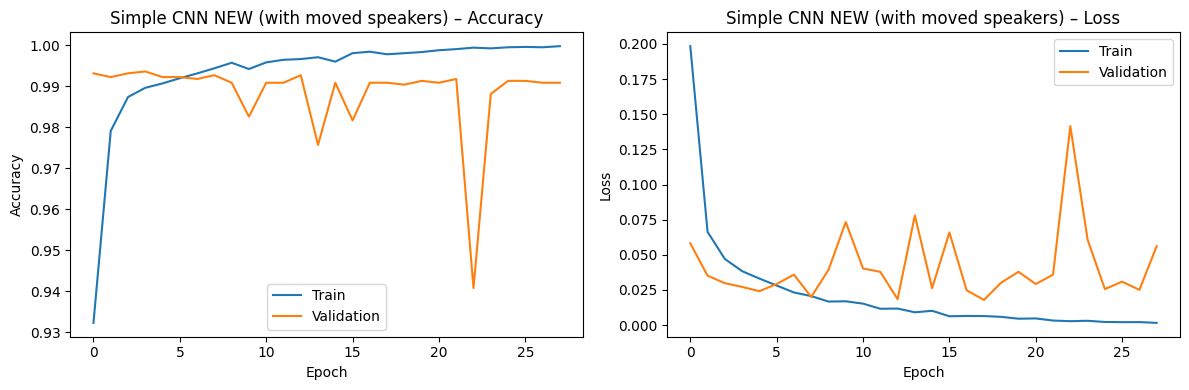

In [ ]:
input_shape = X_train_norm.shape[1:]

simple_cnn_new = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

simple_cnn_new.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

simple_cnn_new.summary()

history_simple_new = simple_cnn_new.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("simple_cnn_mfcc_with_moved_speakers")
)

plot_history(history_simple_new, "Simple CNN NEW (with moved speakers)")

Evaluate NEW Model

In [ ]:
results_simple_new = evaluate_model(simple_cnn_new, X_test_norm, y_test, "Simple CNN NEW (with moved speakers)")


=== Simple CNN NEW (with moved speakers) ===
Accuracy:  0.8025
Recall:    0.9855
Precision: 0.7271
F1-score:  0.8368
AUC-ROC:   0.9792
EER:       0.0677
Bootstrap: 0.8031 [0.7845, 0.8217]


## Improved VGG19 evaluation - Intentional train-test overlap

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, shutil
import numpy as np
import tensorflow as tf
import librosa
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg19 import preprocess_input
from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)

SR              = 16000
DURATION        = 5.0
TARGET_LEN      = int(SR * DURATION)
HOP_LENGTH      = 256
FMIN            = 32.7
N_BINS          = 168
BINS_PER_OCTAVE = 24

drive_path = "/content/drive/MyDrive/Speciale/for-rerecorded 2"
local_path = "/content/for-rerec"

if not os.path.exists(local_path):
    print("Copying FOR data from Drive...")
    shutil.copytree(drive_path, local_path)
else:
    print("FOR data already exists locally")

base_path  = local_path
test_path  = os.path.join(base_path, "testing")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Copying FOR data from Drive...


In [ ]:
def create_cqt(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    C = librosa.cqt(audio, sr=SR, hop_length=HOP_LENGTH, fmin=FMIN, n_bins=N_BINS, bins_per_octave=BINS_PER_OCTAVE)
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
    return C_db.astype(np.float32)


def get_paths(test_path):
    folders = os.listdir(test_path)
    print(f"Folders in testing: {folders}")

    real_folder = None
    fake_folder = None

    for folder in folders:
        if folder.lower() in ['real', 'genuine', 'bonafide', 'bona-fide']:
            real_folder = folder
        elif folder.lower() in ['fake', 'spoofed', 'spoof']:
            fake_folder = folder

    if not real_folder or not fake_folder:
        print(f"ERROR: Could not find real/fake folders in {folders}")
        return None, None

    real_dir = os.path.join(test_path, real_folder)
    fake_dir = os.path.join(test_path, fake_folder)

    real = sorted([os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith(('.wav', '.flac'))])
    fake = sorted([os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith(('.wav', '.flac'))])

    print(f"Found {len(real)} real, {len(fake)} fake")
    return real, fake


def load_test_data(test_path):
    real_paths, fake_paths = get_paths(test_path)
    if not real_paths:
        return None, None

    X, y = [], []

    print(f"Loading {len(real_paths)} real files...")
    for fp in real_paths:
        X.append(create_cqt(fp))
        y.append(1)

    print(f"Loading {len(fake_paths)} fake files...")
    for fp in fake_paths:
        X.append(create_cqt(fp))
        y.append(0)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def preprocess_for_vgg19(X_cqt):
    print("Converting to RGB...")
    X_rgb = []
    for spec in X_cqt:
        spec_rgb = np.stack([spec, spec, spec], axis=-1)
        spec_resized = tf.image.resize(spec_rgb, (224, 224)).numpy()
        X_rgb.append(spec_resized)
    X_rgb = np.array(X_rgb, dtype=np.float32)

    print("Applying VGG19 preprocessing...")
    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)
        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)

    return np.array(X_out, dtype=np.float32)

In [ ]:
def evaluate_model(model, X, y, model_name):
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y, y_pred)
    recall = recall_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)

    print(f"\n{'='*70}")
    print(f"{model_name}")
    print(f"{'='*70}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")

    return {"accuracy": acc, "recall": recall, "precision": prec, "f1": f1, "auc": auc}


print("Loading FOR test data...")
X_for_cqt, y_for = load_test_data(test_path)

if X_for_cqt is not None:
    print(f"Data shape: {X_for_cqt.shape}")

    X_for_vgg = preprocess_for_vgg19(X_for_cqt)
    print(f"Preprocessed shape: {X_for_vgg.shape}")

    print("Loading VGG19 NEW model...")
    vgg19_new = load_model('/content/drive/MyDrive/vgg19_opt_cqt_with_moved_speakers.keras')

    results_for = evaluate_model(vgg19_new, X_for_vgg, y_for, "VGG19 NEW on FOR")

    print(f"\n{'='*70}")
    print("COMPARISON")
    print(f"{'='*70}")
    print(f"Danish test (with moved speakers): 91.08%")
    print(f"FOR test (independent):            {results_for['accuracy']:.2%}")
    print(f"Difference:                        {(results_for['accuracy'] - 0.9108):+.2%}")

Loading FOR test data...
Folders in testing: ['real', 'fake']
Found 408 real, 408 fake
Loading 408 real files...
Loading 408 fake files...
Data shape: (816, 168, 313)
Converting to RGB...
Applying VGG19 preprocessing...
Preprocessed shape: (816, 224, 224, 3)
Loading VGG19 NEW model...

VGG19 NEW on FOR
Accuracy:  0.8456
Recall:    0.9240
Precision: 0.7987
F1-score:  0.8568
AUC-ROC:   0.9382

COMPARISON
Danish test (with moved speakers): 91.08%
FOR test (independent):            84.56%
Difference:                        -6.52%


#Confusion matrices

Preprocess test data (CQT for VGG19, MFCC for Simple CNN)

In [ ]:
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.applications.vgg19 import preprocess_input

print("Creating test data preprocessing...")

SR = 16000
DURATION = 5.0
TARGET_LEN = int(SR * DURATION)
HOP_LENGTH = 256
FMIN = 32.7
N_BINS = 168
BINS_PER_OCTAVE = 24
N_MFCC = 40
N_FFT = 1024

def create_cqt(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    C = librosa.cqt(audio, sr=SR, hop_length=HOP_LENGTH, fmin=FMIN, n_bins=N_BINS, bins_per_octave=BINS_PER_OCTAVE)
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
    return C_db.astype(np.float32)

def create_mfcc(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    return mfcc.astype(np.float32)

def get_test_paths():
    real = sorted([os.path.join(test_path, "real_test_audio", f)
                   for f in os.listdir(os.path.join(test_path, "real_test_audio"))
                   if f.endswith(".wav")])
    fake = sorted([os.path.join(test_path, "fake_test_audio", f)
                   for f in os.listdir(os.path.join(test_path, "fake_test_audio"))
                   if f.endswith(".wav")])
    return real, fake

print("Loading test data...")
real_paths, fake_paths = get_test_paths()

print("Creating CQT features for VGG19...")
X_test_cqt = []
y_test = []

for fp in real_paths:
    X_test_cqt.append(create_cqt(fp))
    y_test.append(1)

for fp in fake_paths:
    X_test_cqt.append(create_cqt(fp))
    y_test.append(0)

X_test_cqt = np.array(X_test_cqt, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

print(f"CQT test data: {X_test_cqt.shape}")

print("Preprocessing CQT for VGG19...")
X_test_rgb = []
for spec in X_test_cqt:
    spec_rgb = np.stack([spec, spec, spec], axis=-1)
    spec_resized = tf.image.resize(spec_rgb, (224, 224)).numpy()
    X_test_rgb.append(spec_resized)
X_test_rgb = np.array(X_test_rgb, dtype=np.float32)

X_test_opt = []
for img in X_test_rgb:
    img_single = img[:, :, 0]
    img_single = np.flipud(img_single)
    img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
    img_preprocessed = preprocess_input(img_stacked)
    X_test_opt.append(img_preprocessed)
X_test_opt = np.array(X_test_opt, dtype=np.float32)

print(f"VGG19 test data ready: {X_test_opt.shape}")

print("Creating MFCC features for Simple CNN...")
X_test_mfcc = []

for fp in real_paths:
    X_test_mfcc.append(create_mfcc(fp))

for fp in fake_paths:
    X_test_mfcc.append(create_mfcc(fp))

X_test_mfcc = np.array(X_test_mfcc, dtype=np.float32)

mean = X_test_mfcc.mean(axis=(0, 1, 2), keepdims=True)
std = X_test_mfcc.std(axis=(0, 1, 2), keepdims=True) + 1e-8
X_test_norm = (X_test_mfcc - mean) / std
X_test_norm = X_test_norm[..., np.newaxis]

print(f"Simple CNN test data ready: {X_test_norm.shape}")

print("\ All test data preprocessed and ready!")
print(f"   Test samples: {len(y_test)}")
print(f"   X_test_opt shape: {X_test_opt.shape} (for VGG19)")
print(f"   X_test_norm shape: {X_test_norm.shape} (for Simple CNN)")

Confusion matrices - original vs new (all 4 models)

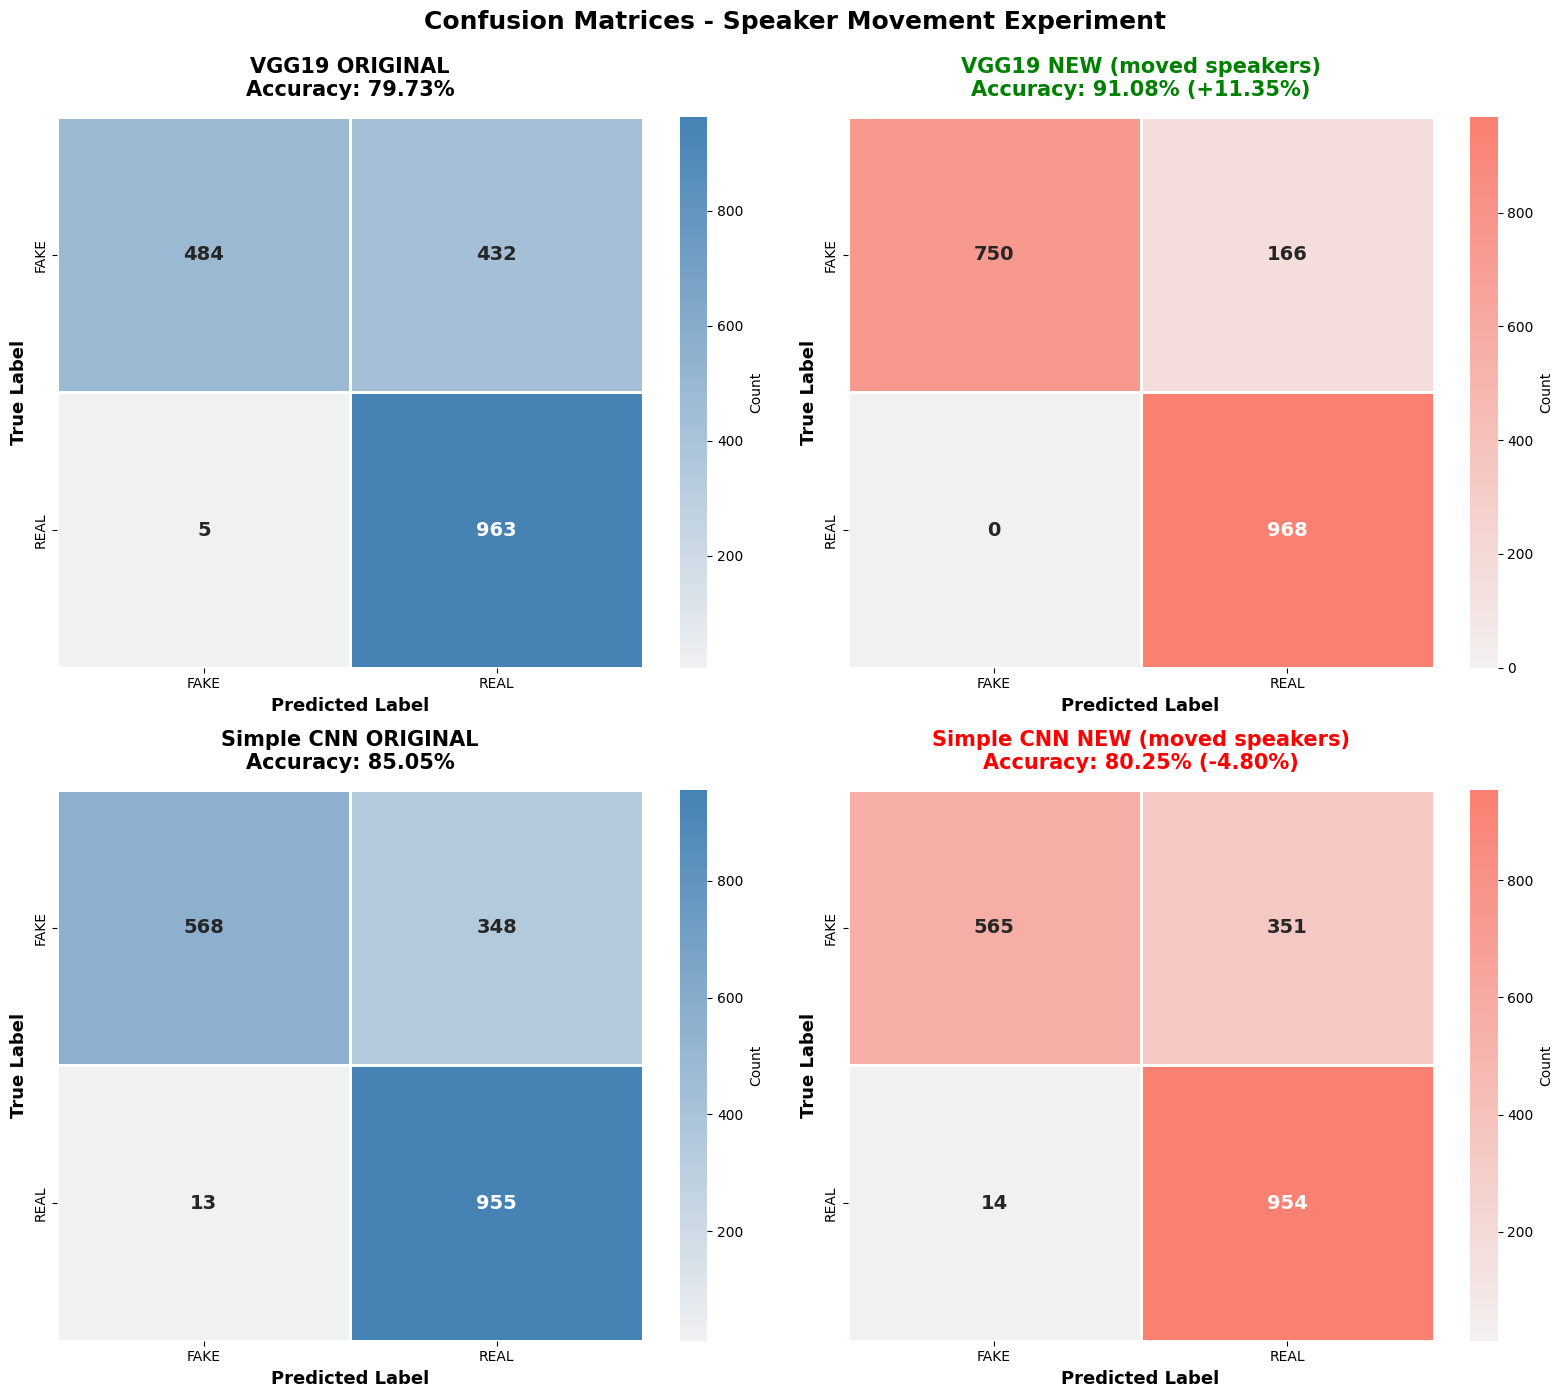

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_vgg_original = confusion_matrix(y_test, y_pred_vgg_original)
cm_vgg_new = confusion_matrix(y_test, y_pred_vgg_new)
cm_simple_original = confusion_matrix(y_test, y_pred_simple_original)
cm_simple_new = confusion_matrix(y_test, y_pred_simple_new)

colors_original = sns.light_palette("steelblue", as_cmap=True)
colors_new = sns.light_palette("salmon", as_cmap=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

sns.heatmap(cm_vgg_original, annot=True, fmt='d', cmap=colors_original,
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'],
            ax=axes[0,0], annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Count'}, linewidths=2, linecolor='white')
axes[0,0].set_title('VGG19 ORIGINAL\nAccuracy: 79.73%', fontsize=15, fontweight='bold', pad=15)
axes[0,0].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')

sns.heatmap(cm_vgg_new, annot=True, fmt='d', cmap=colors_new,
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'],
            ax=axes[0,1], annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Count'}, linewidths=2, linecolor='white')
axes[0,1].set_title('VGG19 NEW (moved speakers)\nAccuracy: 91.08% (+11.35%)',
                    fontsize=15, fontweight='bold', color='green', pad=15)
axes[0,1].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')

sns.heatmap(cm_simple_original, annot=True, fmt='d', cmap=colors_original,
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'],
            ax=axes[1,0], annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Count'}, linewidths=2, linecolor='white')
axes[1,0].set_title('Simple CNN ORIGINAL\nAccuracy: 85.05%', fontsize=15, fontweight='bold', pad=15)
axes[1,0].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')

sns.heatmap(cm_simple_new, annot=True, fmt='d', cmap=colors_new,
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'],
            ax=axes[1,1], annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Count'}, linewidths=2, linecolor='white')
axes[1,1].set_title('Simple CNN NEW (moved speakers)\nAccuracy: 80.25% (-4.80%)',
                    fontsize=15, fontweight='bold', color='red', pad=15)
axes[1,1].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices - Speaker Movement Experiment',
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrices_steelblue_salmon.png', dpi=300, bbox_inches='tight')
plt.show()